In [ ]:
''' 
Dựa vào điểm thi xét tuyển trường IUH cần tuyển những học sinh có điểm thi ưu tiên 
NGONNGU tốt và LOGIC 
vừa phải để phù hợp với nhu cầu đào tạo. Hãy đưa ra đề xuất các nhóm học sinh có kết 
quả phù hợp và căn cứ vào chỉ tiêu (số lượng sinh viên) 
 
Vấn đề đặt ra: Thế nào là tốt? Thế nào là kha khá? -- theo dữ liệu tuyển sinh này --> Tiêu chuẩn chọn lựa mập mờ => Giải pháp 
'''

In [ ]:
# Giải thuật gom cụm (Clustering)  
''' 
Đây là giải thuật có input đầu vào nhưng không có sẵn output đầu ra trong tập dữ liệu lịch 
sử 
Do đó ta gọi là nhóm kỹ thuật un-supervised (học không giám sát) 
 
Để giải quyết nhóm kỹ thuật này ta cần các yếu tố như sau 
1. Dữ liệu đầu vào  
2. Phải có metric (độ đo) để xác định các phần tử sẽ thuộc về đâu 
3. Cần cung cấp trước số lượng cụm (k) được tạo ra 
 
Hệ quả:  
1. Các phần tử thuộc về cùng 1 cụm thì có mức độ gần gũi (theo độ đo đặt ra) hơn so với 
phần tử ở cụm khác 
2. Mỗi cụm sẽ có một đại diện được gọi là trung tâm  
 -> Trong các giải thuật về dạng toán này người ta thường dùng độ đo Euclide để đo lường 
mức độ gần nhau của các phần tử 
 --> Giải thuật điển hình là giải thuật K-Means 
'''

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('dulieuxettuyendaihoc.csv', header=0)
# rename columns TOANLOGICPHANTICH thanh logic, GIAIQUYETVANDE thanh ungxu
df.rename(columns={'TOANLOGICPHANTICH':'LOGIC', 'GIAIQUYETVANDE':'UNGXU','DINHHUONGNGHENGHIEP':'DINHHUONG'}, inplace=True)
df.head()

,MSSV,T1,T2,T3,T4,T5,T6,GT,DT,KV,NGONNGU,LOGIC,UNGXU,KT,NGAYTHI,DINHHUONG
0,SV001,7.2,8.4,7.4,7.2,7.4,6.9,F,NaN,2NT,3.25,3.25,4.50,A1,12/7/2018,No
1,SV002,5.4,6.3,4.3,4.9,3.0,4.0,M,NaN,1,6.00,4.00,3.50,C,12/7/2018,Yes
2,SV003,5.6,5.0,2.8,6.1,4.8,5.7,M,NaN,1,5.00,6.75,4.00,C,12/7/2018,No
3,SV004,6.6,5.1,5.9,4.1,6.1,7.4,M,NaN,1,4.25,4.25,5.25,D1,12/7/2018,No
4,SV005,6.0,5.4,7.6,4.4,6.8,8.0,M,NaN,2NT,4.25,4.50,5.00,A,12/7/2018,No


In [3]:
data = df[['NGONNGU', 'LOGIC']]
data.head(5)

,NGONNGU,LOGIC
0,3.25,3.25
1,6.00,4.00
2,5.00,6.75
3,4.25,4.25
4,4.25,4.50


In [4]:
# Do do Euclid
d = np.sqrt((3.25-6.0)**2+(3.25-4.0)**2)
d

2.850438562747845

In [5]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4).fit(data)

In [6]:
print(kmeans.cluster_centers_)# So tam cua cac cum
print(kmeans.inertia_)  # Do do danh gia
print(kmeans.n_iter_) # So vong lap
print(kmeans.labels_[:]) 



[[3.71621622 4.39864865]
 [2.11290323 4.30645161]
 [6.05555556 6.08333333]
 [5.06521739 3.23913043]]
86.70542983376083
7
[0 3 2 0 0 1 2 0 0 0 0 2 1 1 0 3 0 0 0 0 1 0 3 2 3 3 3 2 0 1 3 0 0 1 1 1 3
 1 1 1 3 0 3 1 0 1 3 2 3 0 1 1 0 1 3 0 2 1 1 0 1 0 3 1 0 1 0 0 0 1 1 0 1 1
 3 3 0 0 0 1 3 1 0 1 2 0 1 1 0 1 3 0 0 0 3 3 3 2 3 3]


In [7]:
def euclid(a1, a2, b1, b2):
    return np.sqrt((a1-b1)**2+(a2-b2)**2)

euclid(3.25, 3.25, 2.11, 4.31)

1.5566630977832037

In [8]:
# Thuat toan
kmeans1 = KMeans(n_clusters=6).fit(data)

In [9]:
print(kmeans1.cluster_centers_)# So tam cua cac cum
print(kmeans1.inertia_)  # Do do danh gia
print(kmeans1.n_iter_) # So vong lap
print(kmeans1.labels_[:])

[[2.16071429 3.58928571]
 [5.22826087 3.36956522]
 [4.1        6.2       ]
 [6.6        6.4       ]
 [3.74305556 4.20833333]
 [2.07352941 4.89705882]]
64.25081686660171
5
[4 1 2 4 4 0 3 4 4 4 4 3 5 0 4 4 4 4 4 4 5 4 1 3 1 1 1 1 4 0 1 4 4 0 5 5 4
 5 0 0 1 4 1 0 4 5 1 2 1 4 5 0 4 5 1 4 3 5 5 4 0 4 1 0 4 0 4 4 2 0 5 4 5 5
 1 1 4 4 4 0 1 5 2 5 1 2 5 0 4 5 1 4 4 4 1 1 1 3 1 1]


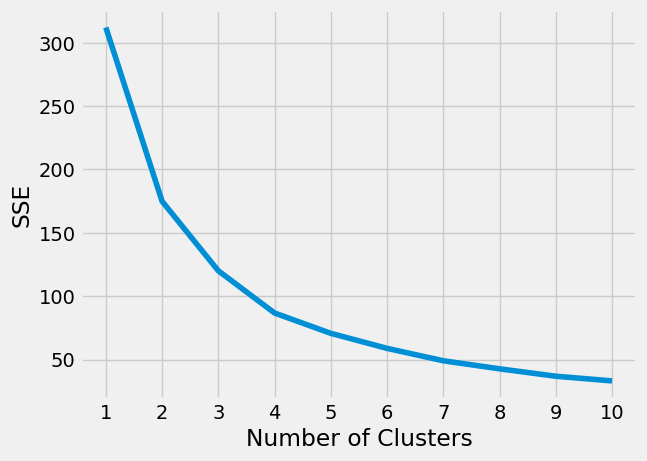

In [10]:
# Chon cum tot nhat 
kmeans_kwargs = { "init": "random", "n_init": 10, "max_iter": 300, "random_state": 42, }
sse = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, **kmeans_kwargs)
    kmeans.fit(data)
    sse.append(kmeans.inertia_)
plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()


In [12]:
# Cach 2
from kneed import KneeLocator
kl = KneeLocator(range(1, 11), sse, curve="convex", direction="decreasing")
print(kl.elbow)

4


In [13]:
# Xay dung ung dung hieu thi danh sach sinh vien va nhan
kmeans = KMeans(n_clusters=4).fit(data)
data['clusterLabel'] = kmeans.labels_[:]
print(data[['NGONNGU', 'LOGIC', 'clusterLabel']])

    NGONNGU  LOGIC  clusterLabel
0      3.25   3.25             1
1      6.00   4.00             2
2      5.00   6.75             3
3      4.25   4.25             1
4      4.25   4.50             1
..      ...    ...           ...
95     5.25   1.50             2
96     5.25   3.75             2
97     7.00   8.00             3
98     5.00   3.50             2
99     5.25   2.50             2

[100 rows x 3 columns]


C:\Users\Admin\AppData\Local\Temp\ipykernel_204\3080534392.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['clusterLabel'] = kmeans.labels_[:]


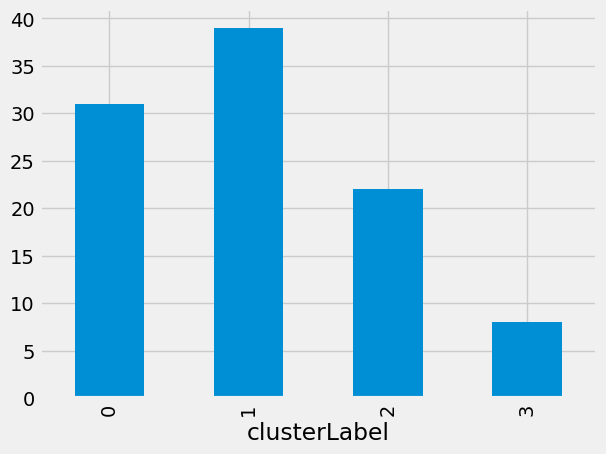

In [15]:
gr_data = data.groupby('clusterLabel').size()
gr_data.plot.bar()
plt.show()

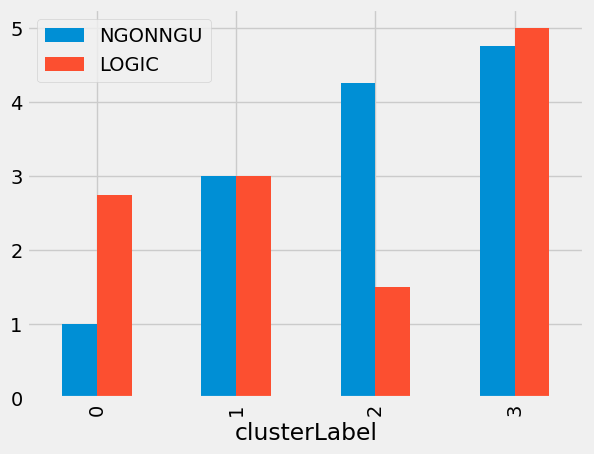

In [16]:
gr_data_min = data.groupby('clusterLabel')[['NGONNGU', 'LOGIC']].min()
gr_data_min.plot.bar()
plt.show()

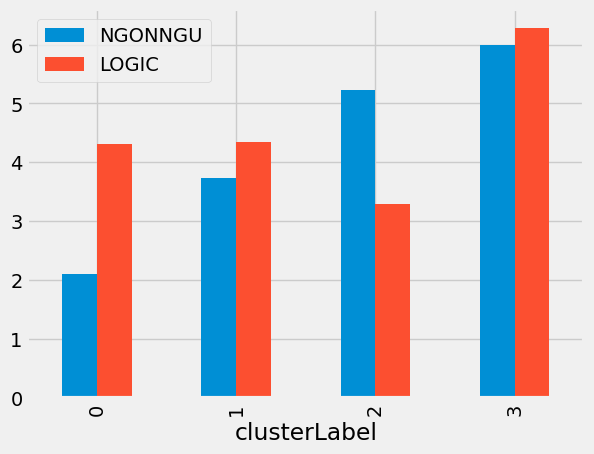

In [17]:
gr_data_mean = data.groupby('clusterLabel')[['NGONNGU', 'LOGIC']].mean()
gr_data_mean.plot.bar()
plt.show()